In [1]:
# CELL 1: Imports and Environment Setup
import os
import random
import json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# New Graph Imports
from torch_geometric.nn import GATConv
from torch_geometric.utils import add_self_loops

import gym
import cityflow
import gym_cityflow

hardware_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active Compute Device: {hardware_device}")

Active Compute Device: cuda


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.


In [5]:
# CELL 2: Graph Architecture and Environment Parsing

def build_city_graph(config_path):
    """Parses the roadnet JSON to build the mathematical graph (edge_index) of intersections."""
    cfg = json.load(open(config_path, "r"))
    roadnet_path = os.path.join(cfg["dir"], cfg["roadnetFile"])
    roadnet = json.load(open(roadnet_path, "r"))

    # Find valid intersections
    valid_nodes = sorted([node["id"] for node in roadnet["intersections"] if not node.get("virtual", False)])
    node_to_index = {node: idx for idx, node in enumerate(valid_nodes)}

    # Map the roads (edges)
    edge_list = []
    for road in roadnet["roads"]:
        start_node = road.get("startIntersection")
        end_node = road.get("endIntersection")
        if start_node in node_to_index and end_node in node_to_index:
            u, v = node_to_index[start_node], node_to_index[end_node]
            edge_list.append([u, v])
            edge_list.append([v, u]) # Bidirectional traffic

    # Convert to PyTorch tensor and add self-loops (so agents consider their own traffic)
    tensor_edges = torch.tensor(edge_list, dtype=torch.long).t().contiguous()
    tensor_edges, _ = add_self_loops(tensor_edges, num_nodes=len(valid_nodes))
    
    return tensor_edges, len(valid_nodes)


class AttentionGraphTrafficBrain(nn.Module):
    """GAT-Dueling Architecture: Agents share info before calculating Value/Advantage."""
    def __init__(self, features_in, num_actions, shared_dims=[64, 64], split_dim=32, heads=4):
        super(AttentionGraphTrafficBrain, self).__init__()
        
        # 1. Graph Attention Layers (The Trunk)
        self.gat_layer_1 = GATConv(features_in, shared_dims[0], heads=heads, concat=True)
        self.gat_layer_2 = GATConv(shared_dims[0] * heads, shared_dims[1], heads=1, concat=False)
        
        # 2. Value Stream [V(s)]
        self.value_head = nn.Sequential(
            nn.Linear(shared_dims[1], split_dim),
            nn.LayerNorm(split_dim),
            nn.ReLU(inplace=True),
            nn.Linear(split_dim, 1)
        )
        
        # 3. Advantage Stream [A(s, a)]
        self.advantage_head = nn.Sequential(
            nn.Linear(shared_dims[1], split_dim),
            nn.LayerNorm(split_dim),
            nn.ReLU(inplace=True),
            nn.Linear(split_dim, num_actions)
        )

    def forward(self, x, edge_idx):
        # Route traffic data through the graph network
        hidden = F.elu(self.gat_layer_1(x, edge_idx))
        hidden = F.elu(self.gat_layer_2(hidden, edge_idx))
        
        # Calculate Dueling Q-Values
        state_value = self.value_head(hidden)
        action_advantages = self.advantage_head(hidden)
        
        q_predictions = state_value + (action_advantages - action_advantages.mean(dim=1, keepdim=True))
        return q_predictions


class RunningRewardScaler:
    # KEEP YOUR EXISTING REWARD SCALER CODE HERE (No changes needed)
    def __init__(self, decay_rate=0.001, epsilon=1e-8):
        self.running_mean = 0.0
        self.running_variance = 1.0
        self.decay_rate = decay_rate
        self.epsilon = epsilon

    def scale(self, reward_array):
        current_mean = np.mean(reward_array)
        current_var = np.var(reward_array)
        self.running_mean += self.decay_rate * (current_mean - self.running_mean)
        self.running_variance += self.decay_rate * (current_var - self.running_variance)
        return (reward_array - self.running_mean) / (np.sqrt(self.running_variance) + self.epsilon)

In [6]:
# CELL 3: Graph-Aware Experience Replay
class GraphExperienceMemory:
    """Stores FULL graphs (all agents simultaneously) so GAT can route messages."""
    def __init__(self, max_capacity, num_agents, feature_dim):
        self.capacity = max_capacity
        self.num_agents = num_agents
        self.ptr = 0
        self.current_count = 0
        
        # Note the extra dimension to preserve the 16-agent graph structure
        self.s_mem = np.zeros((max_capacity, num_agents, feature_dim), dtype=np.float32)
        self.s_next_mem = np.zeros((max_capacity, num_agents, feature_dim), dtype=np.float32)
        self.a_mem = np.zeros((max_capacity, num_agents), dtype=np.int64)
        self.r_mem = np.zeros((max_capacity, num_agents), dtype=np.float32)
        self.done_mem = np.zeros(max_capacity, dtype=np.float32)

    def add_graph_transition(self, states, actions, next_states, rewards, done_flag):
        # Ingests the entire city state as a single interconnected snapshot
        self.s_mem[self.ptr] = states
        self.a_mem[self.ptr] = actions
        self.s_next_mem[self.ptr] = next_states
        self.r_mem[self.ptr] = rewards
        self.done_mem[self.ptr] = float(done_flag)
        
        self.ptr = (self.ptr + 1) % self.capacity
        self.current_count = min(self.current_count + 1, self.capacity)

    def draw_batch(self, sample_size):
        indices = np.random.randint(0, self.current_count, size=sample_size)
        return (
            self.s_mem[indices],
            self.a_mem[indices],
            self.r_mem[indices],
            self.s_next_mem[indices],
            self.done_mem[indices]
        )

    def __len__(self):
        return self.current_count

In [7]:
# CELL 4: Central Multi-Agent Graph Coordinator
class GlobalTrafficCoordinator:
    def __init__(self, state_size, action_size, total_agents, config, base_graph_edges):
        self.action_size = action_size
        self.cfg = config
        self.total_agents = total_agents
        self.base_graph_edges = base_graph_edges.to(hardware_device)
        
        self.explore_rate = config['initial_eps']
        self.explore_floor = config['min_eps']
        self.explore_decay = config['decay_eps']
        
        self.reward_processor = RunningRewardScaler()
        # Initialize the new Graph-Aware Memory
        self.memory = GraphExperienceMemory(config['buffer_limit'], total_agents, state_size)
        
        # Initialize Graph Networks
        self.policy_net = AttentionGraphTrafficBrain(state_size, action_size).to(hardware_device)
        self.stable_net = AttentionGraphTrafficBrain(state_size, action_size).to(hardware_device)
        self.stable_net.load_state_dict(self.policy_net.state_dict())
        self.stable_net.eval()
        
        self.opt = optim.Adam(self.policy_net.parameters(), lr=config['learning_rate'])
        self.interaction_steps = 0

    def pick_actions(self, observations):
        state_t = torch.tensor(np.array(observations), dtype=torch.float32, device=hardware_device)
        with torch.no_grad():
            predictions = self.policy_net(state_t, self.base_graph_edges)
            
        chosen_actions = []
        for i in range(self.total_agents):
            if random.random() < self.explore_rate:
                chosen_actions.append(random.randrange(self.action_size))
            else:
                chosen_actions.append(predictions[i].argmax().item())
        return chosen_actions

    def record_and_train(self, s, a, s_next, r, is_done):
        r_array = np.array(r, dtype=np.float32)
        scaled_r = self.reward_processor.scale(r_array)
        
        # Pass the entire 16-agent lists at once
        self.memory.add_graph_transition(s, a, s_next, scaled_r, is_done)
        
        self.interaction_steps += 1
        if len(self.memory) >= self.cfg['batch_sz'] and self.interaction_steps % self.cfg['update_freq'] == 0:
            self._optimize_weights()
            
        if self.interaction_steps % self.cfg['sync_freq'] == 0:
            self.stable_net.load_state_dict(self.policy_net.state_dict())

    def decay_exploration(self):
        self.explore_rate = max(self.explore_floor, self.explore_rate * self.explore_decay)

    def _build_batch_edges(self, batch_sz):
        """Fixes PyG batching by tiling the graph edges across the batch dimension."""
        num_edges = self.base_graph_edges.shape[1]
        batched_edges = self.base_graph_edges.repeat(1, batch_sz)
        offsets = torch.arange(batch_sz, device=hardware_device).repeat_interleave(num_edges) * self.total_agents
        return batched_edges + offsets

    def _optimize_weights(self):
        s_b, a_b, r_b, s_next_b, done_b = self.memory.draw_batch(self.cfg['batch_sz'])
        batch_sz = s_b.shape[0]
        
        # Flatten the graphs sequentially for PyTorch Geometric (Batch Size * 16 Agents)
        states = torch.FloatTensor(s_b.reshape(-1, self.cfg['state_dim'])).to(hardware_device)
        next_states = torch.FloatTensor(s_next_b.reshape(-1, self.cfg['state_dim'])).to(hardware_device)
        actions = torch.LongTensor(a_b.reshape(-1, 1)).to(hardware_device)
        rewards = torch.FloatTensor(r_b.reshape(-1, 1)).to(hardware_device)
        
        # Dones apply to the whole graph, so we repeat the flag for all 16 agents
        repeated_dones = np.repeat(done_b, self.total_agents)
        dones = torch.FloatTensor(repeated_dones.reshape(-1, 1)).to(hardware_device)

        # Generate block-diagonal edges for the batch
        batch_edge_index = self._build_batch_edges(batch_sz)

        # Double DQN + GAT Target Calculation
        current_q = self.policy_net(states, batch_edge_index).gather(1, actions)
        with torch.no_grad():
            best_future_actions = self.policy_net(next_states, batch_edge_index).argmax(dim=1, keepdim=True)
            future_q = self.stable_net(next_states, batch_edge_index).gather(1, best_future_actions)
            target_q = rewards + self.cfg['gamma'] * future_q * (1 - dones)

        loss = F.smooth_l1_loss(current_q, target_q)
        
        self.opt.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.policy_net.parameters(), self.cfg['grad_clip'])
        self.opt.step()

In [10]:
# CELL 5: Training Execution Logic
def execute_simulation_run(env_cfg_path, hyperparams):
    save_directory = Path("project_weights") / "gat_d3qn_run" # Changed folder name
    save_directory.mkdir(parents=True, exist_ok=True)
    
    # NEW: Build the mathematical graph
    city_edges, expected_agents = build_city_graph(env_cfg_path)
    
    simulator = gym.make(id='cityflow-v0', configPath=env_cfg_path, episodeSteps=hyperparams['max_steps'])
    initial_reading = simulator.reset()
    traffic_nodes = sorted(initial_reading.keys())
    
    total_eps = hyperparams['episodes']
    hyperparams['decay_eps'] = (hyperparams['min_eps'] / hyperparams['initial_eps']) ** (1.0 / total_eps)
    
    # NEW: Pass edges into Coordinator
    coordinator = GlobalTrafficCoordinator(
        state_size=hyperparams['state_dim'],
        action_size=hyperparams['action_dim'],
        total_agents=len(traffic_nodes),
        config=hyperparams,
        base_graph_edges=city_edges 
    )
    
    performance_log = []

    # THE REST OF YOUR TRAINING LOOP REMAINS EXACTLY THE SAME!
    for episode in range(1, total_eps + 1):
        # Reset with random seed
        simulator.seed(np.random.randint(0, 999999))
        raw_state = simulator.reset()
        
        # Format State
        current_state = [np.array(raw_state[node], dtype=np.float32).flatten() for node in traffic_nodes]
        cumulative_score = 0

        for step in range(hyperparams['max_steps']):
            # Act
            action_vector = coordinator.pick_actions(current_state)
            
            # Step Simulator
            raw_next_state, raw_rewards, is_terminal, _ = simulator.step(action_vector)
            
            # Format Next State & Rewards
            next_state = [np.array(raw_next_state[node], dtype=np.float32).flatten() for node in traffic_nodes]
            reward_mapping = dict(raw_rewards)
            reward_vector = [reward_mapping[node] for node in traffic_nodes]
            
            cumulative_score += sum(reward_vector)

            # Record and Learn
            coordinator.record_and_train(current_state, action_vector, next_state, reward_vector, is_terminal)
            
            current_state = next_state
            if is_terminal:
                break

        coordinator.decay_exploration()
        performance_log.append(cumulative_score)
        
        print(f"Run {episode:04d} | Score: {cumulative_score:8.1f} | Exploration Rate: {coordinator.explore_rate:.3f}")

        # Specific Checkpointing
        if episode % hyperparams['save_interval'] == 0:
            ckpt_file = save_directory / f"d3qn_gat_{episode}.pth"
            torch.save(coordinator.policy_net.state_dict(), ckpt_file)
            print(f"--> Checkpoint secured: {ckpt_file.name}")

    # Final Save
    final_file = save_directory / "loop_d3qn_gat.pth"
    torch.save(coordinator.policy_net.state_dict(), final_file)
    print(f"\nTraining Complete. Final model stored at {final_file}")
    
    simulator.close()
    return performance_log

Run 0001 | Score: -974593.2 | Exploration Rate: 0.994
Run 0002 | Score: -969221.4 | Exploration Rate: 0.988
Run 0003 | Score: -973758.6 | Exploration Rate: 0.982
Run 0004 | Score: -930882.6 | Exploration Rate: 0.976
Run 0005 | Score: -963498.0 | Exploration Rate: 0.970
Run 0006 | Score: -1005028.8 | Exploration Rate: 0.965
Run 0007 | Score: -931534.2 | Exploration Rate: 0.959
Run 0008 | Score: -895197.6 | Exploration Rate: 0.953
Run 0009 | Score: -936976.8 | Exploration Rate: 0.948
Run 0010 | Score: -921987.0 | Exploration Rate: 0.942
Run 0011 | Score: -861027.6 | Exploration Rate: 0.936
Run 0012 | Score: -918564.0 | Exploration Rate: 0.931
Run 0013 | Score: -975846.0 | Exploration Rate: 0.925
Run 0014 | Score: -878312.4 | Exploration Rate: 0.920
Run 0015 | Score: -965186.4 | Exploration Rate: 0.914
Run 0016 | Score: -910506.0 | Exploration Rate: 0.909
Run 0017 | Score: -935590.8 | Exploration Rate: 0.903
Run 0018 | Score: -890640.6 | Exploration Rate: 0.898
Run 0019 | Score: -853732.8

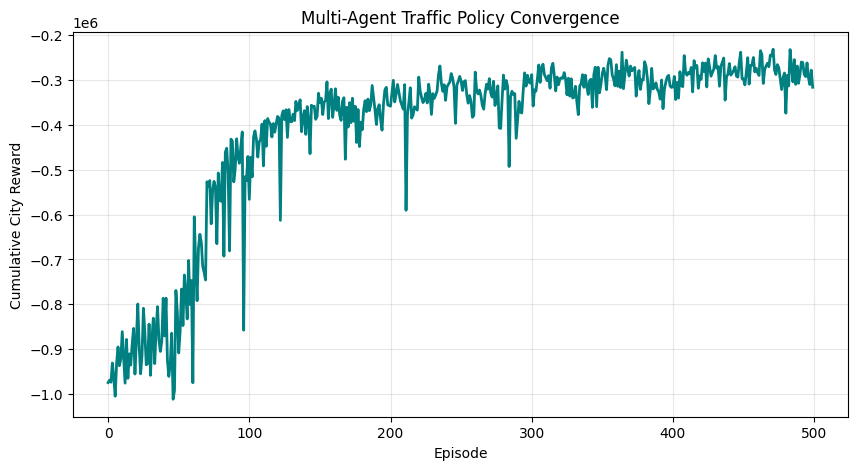

In [12]:
# CELL 6: Configuration and Execution
config_parameters = {
    'episodes': 500,
    'max_steps': 1000,
    'state_dim': 72,
    'action_dim': 9,
    'buffer_limit': 15000, # Per agent, total buffer is 15000 * num_agents
    'batch_sz': 128,
    'update_freq': 4,
    'sync_freq': 8,
    'learning_rate': 1e-4,
    'gamma': 0.99, # Updated from 0.8 to better handle delayed traffic rewards
    'initial_eps': 1.0,
    'min_eps': 0.05,
    'grad_clip': 1.0,
    'save_interval': 250
}

# Run the pipeline
# NOTE: Ensure "../configs/Intersections_4/sample_config.json" exists in your directory
training_history = execute_simulation_run("../configs/Intersections_4/sample_config.json", config_parameters)

# Plotting the Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(training_history, color='teal', linewidth=2)
plt.title("Multi-Agent Traffic Policy Convergence")
plt.xlabel("Episode")
plt.ylabel("Cumulative City Reward")
plt.grid(True, alpha=0.3)   
plt.show()